***Pre Feature Engineering Baseline Multiclass Models***
Goal: Train baseline multiclass models for next-3h risk class, evaluate with recall focus, tune High-risk threshold τ.


In [11]:

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score,mean_squared_error
)

import matplotlib.pyplot as plt
import joblib

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
SUPERVISED_PATH = DATA_DIR / "supervised_baseline_3h.csv"

In [12]:
# --- Load supervised dataset ---
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)
df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce").astype("int8")
df = df.sort_values(["time_3h","HOOD_158_CODE"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Class distribution:")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))

Shape: (1385186, 29)
Class distribution:
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


In [13]:
# --- Time-based split ---
t = df["time_3h"]
train_end = pd.Timestamp("2024-12-31 23:59:59")
val_end   = pd.Timestamp("2025-06-30 23:59:59")

train_mask = t <= train_end
val_mask   = (t > train_end) & (t <= val_end)
test_mask  = t > val_end

y = df["y_class"].copy()
X = df.drop(columns=[c for c in ["y_class","y_count_next"] if c in df.columns], errors="ignore").copy()

# Do not use raw timestamp as feature (we already have time features)
X = X.drop(columns=["time_3h"], errors="ignore")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val     = X.loc[val_mask], y.loc[val_mask]
X_test, y_test   = X.loc[test_mask], y.loc[test_mask]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test: (923984, 26) (228784, 26) (232418, 26)


In [14]:
# --- Identify categorical and numeric columns ---
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")

num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Numeric:", len(num_cols), "Categorical:", len(cat_cols), cat_cols)

Numeric: 25 Categorical: 1 ['HOOD_158_CODE']


In [15]:

# --- Preprocess: impute + scale numeric, one-hot categorical ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

In [16]:
# --- Helpers for evaluation ---
def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    fig, ax = plt.subplots()
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def eval_multiclass(y_true, y_pred, proba=None, name="Model"):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    cm = confusion_matrix(y_true_arr, y_pred_arr, labels=[0, 1, 2])
    rec = recall_score(y_true_arr, y_pred_arr, labels=[0, 1, 2], average=None, zero_division=0)
    macro_rec = recall_score(y_true_arr, y_pred_arr, average="macro", zero_division=0)
    rec2 = recall_score((y_true_arr == 2).astype(int), (y_pred_arr == 2).astype(int), zero_division=0)
    prec2 = precision_score((y_true_arr == 2).astype(int), (y_pred_arr == 2).astype(int), zero_division=0)
    pred2_rate = float((y_pred_arr == 2).mean())
    label_rmse = float(np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)))

    out = {
        "model": name,
        "recall_0": float(rec[0]),
        "recall_1": float(rec[1]),
        "recall_2": float(rec[2]),
        "macro_recall": float(macro_rec),
        "recall_high": float(rec2),
        "precision_high": float(prec2),
        "precision_2": float(prec2),
        "pred2_rate": float(pred2_rate),
        "pred_class2_rate": float(pred2_rate),
        "label_rmse": label_rmse,
    }

    ap_vals = []
    prob_rmse_vals = []
    if proba is not None:
        proba_arr = np.asarray(proba, dtype=float)
        supports = np.bincount(y_true_arr.astype(int), minlength=3).astype(float)

        for k in range(3):
            try:
                ap_k = float(average_precision_score((y_true_arr == k).astype(int), proba_arr[:, k]))
            except Exception:
                ap_k = np.nan
            out[f"ap_class{k}"] = ap_k
            ap_vals.append(ap_k)

            try:
                rmse_k = float(np.sqrt(mean_squared_error((y_true_arr == k).astype(int), proba_arr[:, k])))
            except Exception:
                rmse_k = np.nan
            out[f"prob_rmse_class{k}"] = rmse_k
            prob_rmse_vals.append(rmse_k)

        out["macro_map"] = float(np.nanmean(ap_vals))
        valid = np.array([not np.isnan(x) for x in ap_vals], dtype=bool)
        if valid.any():
            out["weighted_map"] = float(np.average(np.array(ap_vals)[valid], weights=supports[valid]))
        else:
            out["weighted_map"] = np.nan
        out["prob_rmse_macro"] = float(np.nanmean(prob_rmse_vals))
    else:
        for k in range(3):
            out[f"ap_class{k}"] = np.nan
            out[f"prob_rmse_class{k}"] = np.nan
        out["macro_map"] = np.nan
        out["weighted_map"] = np.nan
        out["prob_rmse_macro"] = np.nan

    print(f"\\n=== {name} ===")
    print("Per-class recall [0,1,2]:", np.round([out["recall_0"], out["recall_1"], out["recall_2"]], 4))
    print("Macro recall:", round(out["macro_recall"], 4))
    print("Per-class AP [0,1,2]:", np.round([out["ap_class0"], out["ap_class1"], out["ap_class2"]], 4))
    print("Macro MAP:", round(out["macro_map"], 4), "| Weighted MAP:", round(out["weighted_map"], 4))
    print("Class-label RMSE:", round(out["label_rmse"], 4), "| Probability RMSE (macro):", round(out["prob_rmse_macro"], 4))
    print("High-risk recall:", round(out["recall_high"], 4), "| High-risk precision:", round(out["precision_2"], 4))
    print("Predicted class-2 rate:", round(out["pred2_rate"], 4))
    print("\\n", classification_report(y_true_arr, y_pred_arr, digits=4, zero_division=0))

    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.xticks([0, 1, 2], [0, 1, 2])
    plt.yticks([0, 1, 2], [0, 1, 2])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(name)
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()
    return out



/var/folders/lj/6gj8xmr10fl6dc46ffl6h60h0000gn/T/ipykernel_10533/1226492166.py:64: RuntimeWarning: Mean of empty slice
  out["macro_map"] = float(np.nanmean(ap_vals))


\n=== Dummy (Most Frequent) - Val ===
Per-class recall [0,1,2]: [1. 0. 0.]
Macro recall: 0.3333
Per-class AP [0,1,2]: [nan nan nan]
Macro MAP: nan | Weighted MAP: nan
Class-label RMSE: 0.3838 | Probability RMSE (macro): 0.248
High-risk recall: 0.0 | High-risk precision: 0.0
Predicted class-2 rate: 0.0
\n               precision    recall  f1-score   support

           0     0.8951    1.0000    0.9447    204791
           1     0.0000    0.0000    0.0000     20758
           2     0.0000    0.0000    0.0000      3235

    accuracy                         0.8951    228784
   macro avg     0.2984    0.3333    0.3149    228784
weighted avg     0.8013    0.8951    0.8456    228784



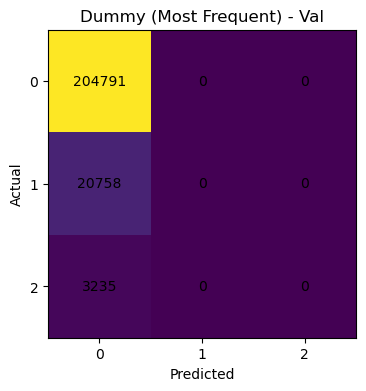

In [17]:
# --- Baseline 1: Dummy (most frequent) ---
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
pred_val = dummy.predict(X_val)
eval_multiclass(y_val, pred_val, dummy.predict_proba(X_val), name="Dummy (Most Frequent) - Val")
def apply_two_thresholds(proba, tau1, tau2):
    """
    Decision rule:
      if P2 >= tau2 -> 2
      elif P1 >= tau1 -> 1
      else -> 0
    """
    p1 = proba[:, 1]
    p2 = proba[:, 2]
    pred = np.zeros(len(p1), dtype=int)
    pred[p1 >= tau1] = 1
    pred[p2 >= tau2] = 2  # overwrite -> class 2 wins
    return pred

def tune_two_thresholds(proba_val, y_val,
                        tau1_grid=np.linspace(0.20, 0.70, 11),
                        tau2_grid=np.linspace(0.05, 0.40, 15),
                        min_recall_1=0.25,
                        max_pred2_rate=0.15):
    rows = []
    for tau1 in tau1_grid:
        for tau2 in tau2_grid:
            pred = apply_two_thresholds(proba_val, tau1, tau2)
            rec = recall_score(y_val, pred, labels=[0,1,2], average=None, zero_division=0)
            macro = recall_score(y_val, pred, average="macro", zero_division=0)
            rec_high = recall_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            prec_high = precision_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            pred2_rate = float((pred==2).mean())
            rows.append((tau1, tau2, macro, rec[1], rec_high, prec_high, pred2_rate))
    df = pd.DataFrame(rows, columns=["tau1","tau2","macro_recall","recall_1","recall_2","precision_2","pred2_rate"])
    feasible = df[(df["recall_1"] >= min_recall_1) & (df["pred2_rate"] <= max_pred2_rate)]
    best = (feasible if len(feasible) else df).sort_values(
        ["macro_recall","recall_2","precision_2"], ascending=False
    ).iloc[0]
    return float(best["tau1"]), float(best["tau2"]), df

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


\n=== LogReg Argmax - Val ===
Per-class recall [0,1,2]: [0.6544 0.3432 0.6056]
Macro recall: 0.5344
Per-class AP [0,1,2]: [nan nan nan]
Macro MAP: nan | Weighted MAP: nan
Class-label RMSE: 0.8329 | Probability RMSE (macro): 0.3886
High-risk recall: 0.6056 | High-risk precision: 0.0591
Predicted class-2 rate: 0.1449
\n               precision    recall  f1-score   support

           0     0.9518    0.6544    0.7755    204791
           1     0.1299    0.3432    0.1885     20758
           2     0.0591    0.6056    0.1077      3235

    accuracy                         0.6255    228784
   macro avg     0.3803    0.5344    0.3572    228784
weighted avg     0.8646    0.6255    0.7128    228784



/var/folders/lj/6gj8xmr10fl6dc46ffl6h60h0000gn/T/ipykernel_10533/1226492166.py:64: RuntimeWarning: Mean of empty slice
  out["macro_map"] = float(np.nanmean(ap_vals))


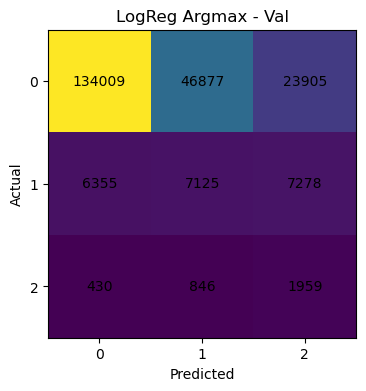

\n=== LogReg Argmax - Test ===
Per-class recall [0,1,2]: [0.6358 0.3268 0.6784]
Macro recall: 0.547
Per-class AP [0,1,2]: [nan nan nan]
Macro MAP: nan | Weighted MAP: nan
Class-label RMSE: 0.8685 | Probability RMSE (macro): 0.3965
High-risk recall: 0.6784 | High-risk precision: 0.0604
Predicted class-2 rate: 0.1649
\n               precision    recall  f1-score   support

           0     0.9542    0.6358    0.7632    207818
           1     0.1245    0.3268    0.1803     21189
           2     0.0604    0.6784    0.1109      3411

    accuracy                         0.6083    232418
   macro avg     0.3797    0.5470    0.3514    232418
weighted avg     0.8655    0.6083    0.7004    232418



/var/folders/lj/6gj8xmr10fl6dc46ffl6h60h0000gn/T/ipykernel_10533/1226492166.py:64: RuntimeWarning: Mean of empty slice
  out["macro_map"] = float(np.nanmean(ap_vals))


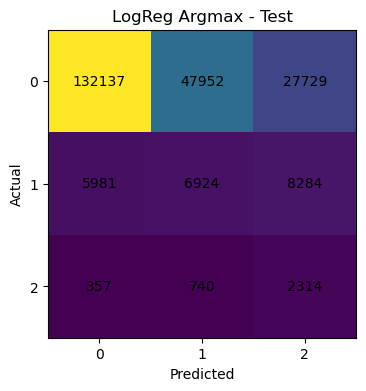

In [18]:
# --- Baseline 2: Logistic Regression (convergence fix) ---
logreg = LogisticRegression(
    solver="saga",
    max_iter=2000,   # fix convergence
    tol=1e-3,
    n_jobs=-1,
    class_weight="balanced"
)

logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

logreg_pipe.fit(X_train, y_train)

pred_val = logreg_pipe.predict(X_val)
eval_multiclass(y_val, pred_val, logreg_pipe.predict_proba(X_val), name="LogReg Argmax - Val")

pred_test = logreg_pipe.predict(X_test)
eval_multiclass(y_test, pred_test, logreg_pipe.predict_proba(X_test), name="LogReg Argmax - Test")
def apply_two_thresholds(proba, tau1, tau2):
    """
    Decision rule:
      if P2 >= tau2 -> 2
      elif P1 >= tau1 -> 1
      else -> 0
    """
    p1 = proba[:, 1]
    p2 = proba[:, 2]
    pred = np.zeros(len(p1), dtype=int)
    pred[p1 >= tau1] = 1
    pred[p2 >= tau2] = 2  # overwrite -> class 2 wins
    return pred

def tune_two_thresholds(proba_val, y_val,
                        tau1_grid=np.linspace(0.20, 0.70, 11),
                        tau2_grid=np.linspace(0.05, 0.40, 15),
                        min_recall_1=0.25,
                        max_pred2_rate=0.15):
    rows = []
    for tau1 in tau1_grid:
        for tau2 in tau2_grid:
            pred = apply_two_thresholds(proba_val, tau1, tau2)
            rec = recall_score(y_val, pred, labels=[0,1,2], average=None, zero_division=0)
            macro = recall_score(y_val, pred, average="macro", zero_division=0)
            rec_high = recall_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            prec_high = precision_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            pred2_rate = float((pred==2).mean())
            rows.append((tau1, tau2, macro, rec[1], rec_high, prec_high, pred2_rate))
    df = pd.DataFrame(rows, columns=["tau1","tau2","macro_recall","recall_1","recall_2","precision_2","pred2_rate"])
    feasible = df[(df["recall_1"] >= min_recall_1) & (df["pred2_rate"] <= max_pred2_rate)]
    best = (feasible if len(feasible) else df).sort_values(
        ["macro_recall","recall_2","precision_2"], ascending=False
    ).iloc[0]
    return float(best["tau1"]), float(best["tau2"]), df

Chosen thresholds: {'tau1': 0.35, 'tau2': 0.4}


,tau1,tau2,macro_recall,recall_1,recall_2,precision_2,pred2_rate
72,0.40,0.350,0.530705,0.228249,0.686862,0.051700,0.187858
71,0.40,0.325,0.529648,0.201561,0.720556,0.047423,0.214845
73,0.40,0.375,0.529000,0.254890,0.645440,0.056039,0.162861
59,0.35,0.400,0.528836,0.454138,0.606801,0.060949,0.140775
57,0.35,0.350,0.528736,0.377252,0.686862,0.051700,0.187858
58,0.35,0.375,0.528642,0.416562,0.645440,0.056039,0.162861
74,0.40,0.400,0.527189,0.278832,0.606801,0.060949,0.140775
56,0.35,0.325,0.526124,0.338038,0.720556,0.047423,0.214845
70,0.40,0.300,0.526099,0.172126,0.750541,0.043272,0.245253
69,0.40,0.275,0.522391,0.141584,0.782998,0.039674,0.279062


\n=== LogReg Two-Threshold (tau1=0.35, tau2=0.40) - Test ===
Per-class recall [0,1,2]: [0.5135 0.4336 0.6772]
Macro recall: 0.5414
Per-class AP [0,1,2]: [nan nan nan]
Macro MAP: nan | Weighted MAP: nan
Class-label RMSE: 0.914 | Probability RMSE (macro): 0.3965
High-risk recall: 0.6772 | High-risk precision: 0.0625
Predicted class-2 rate: 0.1591
\n               precision    recall  f1-score   support

           0     0.9639    0.5135    0.6701    207818
           1     0.1084    0.4336    0.1735     21189
           2     0.0625    0.6772    0.1144      3411

    accuracy                         0.5086    232418
   macro avg     0.3783    0.5414    0.3193    232418
weighted avg     0.8727    0.5086    0.6166    232418



/var/folders/lj/6gj8xmr10fl6dc46ffl6h60h0000gn/T/ipykernel_10533/1226492166.py:64: RuntimeWarning: Mean of empty slice
  out["macro_map"] = float(np.nanmean(ap_vals))


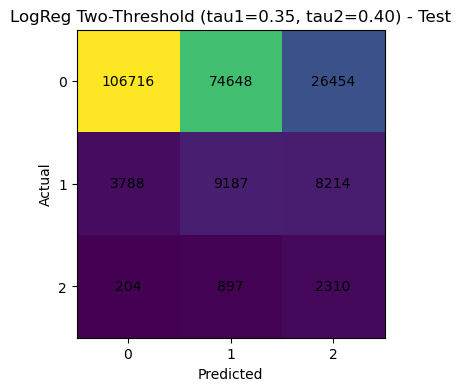

{'model': 'LogReg Two-Threshold (tau1=0.35, tau2=0.40) - Test',
 'recall_0': 0.5135070109422668,
 'recall_1': 0.4335740242578697,
 'recall_2': 0.6772207563764292,
 'macro_recall': 0.5414339305255219,
 'recall_high': 0.6772207563764292,
 'precision_high': 0.06246957650494889,
 'precision_2': 0.06246957650494889,
 'pred2_rate': 0.15910127442797029,
 'pred_class2_rate': 0.15910127442797029,
 'label_rmse': 0.9140422069707067,
 'ap_class0': nan,
 'prob_rmse_class0': 0.5407642259389726,
 'ap_class1': nan,
 'prob_rmse_class1': 0.36961634712171815,
 'ap_class2': nan,
 'prob_rmse_class2': 0.2789712714840096,
 'macro_map': nan,
 'weighted_map': nan,
 'prob_rmse_macro': 0.3964506148482334}

In [19]:
# --- Two-threshold tuning (Val) and apply on Test ---
proba_val = logreg_pipe.predict_proba(X_val)
tau1, tau2, grid = tune_two_thresholds(proba_val, y_val, min_recall_1=0.25, max_pred2_rate=0.15)
print("Chosen thresholds:", {"tau1": tau1, "tau2": tau2})
display(grid.sort_values(["macro_recall","recall_2","precision_2"], ascending=False).head(10))

pred_test_thr = apply_two_thresholds(logreg_pipe.predict_proba(X_test), tau1, tau2)
eval_multiclass(y_test, pred_test_thr, logreg_pipe.predict_proba(X_test), name=f"LogReg Two-Threshold (tau1={tau1:.2f}, tau2={tau2:.2f}) - Test")